# 📚 Section 9. Subplots & Practical Dashboard Layout (Matplotlib)
> 섹션 9. 서브플롯 & 실무 대시보드 레이아웃 (Matplotlib)

---
# 🎯 Learning Objective · 학습 목표
Today I want to learn: · 오늘 배우고 싶은 것:
- [x] Use GridSpec to make one panel span multiple cells, and control relative panel sizes with width_ratios/height_ratios  
GridSpec으로 한 패널이 여러 칸에 걸치게 만들고, width_ratios/height_ratios로 패널 크기 비율 조절하기
- [x] Use subplot_mosaic to lay out panels from a string that looks like the final layout  
subplot_mosaic으로 최종 배치 모양 그대로인 문자열을 이용해 패널 배치하기
- [x] Build a full one-page KPI dashboard combining number cards, a trend line, a pie chart, and a bar chart in one Figure  
숫자 카드, 추세선, 파이 차트, 막대 차트를 하나의 Figure로 결합한 원페이지 KPI 대시보드 만들기

---
# 🧠 Concept · 개념

## What is it? · 무엇인가?

This section covers systematically arranging several individual charts inside one Figure. Section 2 already taught `plt.subplots(nrows, ncols)` for an evenly-sized grid — this section goes further: panels of different sizes, a single chart spanning multiple cells, and laying out panels by name instead of by index.

여러 개의 개별 차트를 하나의 Figure 안에 체계적으로 배치하는 기술을 다룹니다. 섹션 2에서는 이미 `plt.subplots(nrows, ncols)`로 균등한 격자 배치를 배웠습니다 — 이 섹션에서는 한 걸음 더 나아가, 크기가 서로 다른 패널, 여러 칸을 가로지르는 차트, 인덱스가 아닌 이름으로 배치하는 방법까지 다룹니다.

## Why do we use it? · 왜 사용하는가?

Use it whenever a single chart can't tell the whole story. If a report needs "how much" (a number), "how did it change" (a trend), and "what's it made of" (composition) all at once, those need to live in one image, side by side.

하나의 차트만으로는 전체 그림을 설명할 수 없을 때 사용합니다. 보고서가 "얼마인지"(숫자), "어떻게 변했는지"(추세), "무엇으로 구성되는지"(비율)를 한 번에 담아야 한다면, 이 모든 것이 하나의 이미지 안에 나란히 있어야 합니다.

## When is it used in Business Analytics? · 언제 비즈니스 분석에서 사용되는가?

DA/BA situations: weekly/monthly KPI reports, one-page executive dashboards, compressing several angles of analysis (trend + comparison + composition) into a single image to share over Slack or email.

DA/BA 실무 상황: 주간·월간 KPI 리포트, 경영진 보고용 "원페이저(one-pager)" 대시보드, 여러 관점(추세+비교+구성)의 분석 결과를 하나의 이미지로 압축해 슬랙이나 이메일로 공유할 때.

| Technique / 기법 | Trait / 특징 | Use when / 언제 사용 |
|---|---|---|
| `plt.subplots(n, m)` | Every cell is the same size / 모든 칸이 동일한 크기의 격자 | All panels are equally important / 비교 대상 차트들이 서로 대등한 중요도일 때 (섹션 2) |
| `GridSpec` | Cells can differ in size, panels can span multiple cells / 칸 크기를 다르게, 여러 칸에 걸친 배치 가능 | One key chart should be large, supporting ones small / 핵심 차트 하나를 크게, 보조 차트들을 작게 배치할 때 |
| `subplot_mosaic` | The layout is written as a string that looks like the final picture / 문자열로 레이아웃을 그림처럼 직접 그려서 정의 | You want a complex layout to be readable straight from the code / 복잡한 배치를 코드만 보고도 직관적으로 이해하고 싶을 때 |

---
# 📝 Syntax · 문법

## Basic Syntax · 기본 문법

`fig.add_gridspec(nrows, ncols)` creates an invisible "blueprint," not an actual chart. Slice it exactly like a numpy array — `gs[0, :]` means "row 0, every column" — and pass the slice into `fig.add_subplot()` to get an Axes as wide as that slice.

`fig.add_gridspec(nrows, ncols)`는 실제 차트가 아니라 보이지 않는 "설계도"를 만듭니다. numpy 배열처럼 그대로 슬라이싱할 수 있으며 — `gs[0, :]`는 "0번 행의 모든 열"을 의미합니다 — 그 슬라이스를 `fig.add_subplot()`에 넘기면 슬라이스한 범위만큼 넓은 Axes가 만들어집니다.

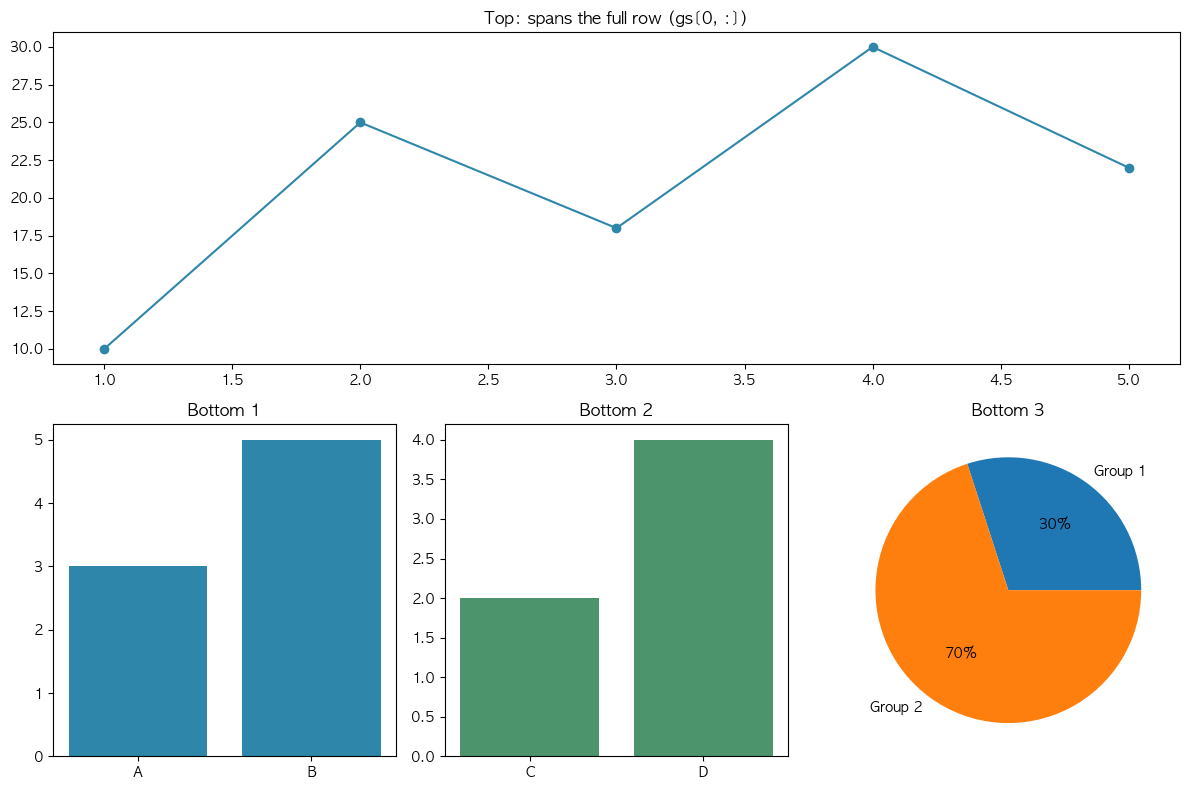

In [1]:
# Basic Syntax: one panel spanning an entire row via GridSpec slicing
# 기본 문법: GridSpec 슬라이싱으로 한 패널이 행 전체를 차지하게 만들기

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'   # macOS: 'AppleGothic', Windows: 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 3)   # a 2-row, 3-column invisible blueprint

ax1 = fig.add_subplot(gs[0, :])   # row 0, all columns -> spans the full top row
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[1, 2])

ax1.plot([1, 2, 3, 4, 5], [10, 25, 18, 30, 22], marker='o', color='#2E86AB')
ax1.set_title('Top: spans the full row (gs[0, :])')

ax2.bar(['A', 'B'], [3, 5], color='#2E86AB')
ax2.set_title('Bottom 1')
ax3.bar(['C', 'D'], [2, 4], color='#4C956C')
ax3.set_title('Bottom 2')
ax4.pie([30, 70], labels=['Group 1', 'Group 2'], autopct='%1.0f%%')
ax4.set_title('Bottom 3')

plt.tight_layout()
plt.show()

## Common Variations · 주요 변형

`width_ratios`/`height_ratios` set relative panel sizes. `width_ratios=[2, 1]` means the left cell is exactly twice as wide as the right one — use `height_ratios` for the vertical equivalent.

`width_ratios`/`height_ratios`는 패널의 상대적 크기를 지정합니다. `width_ratios=[2, 1]`은 왼쪽 칸이 오른쪽 칸보다 정확히 2배 넓다는 뜻입니다 — 세로 방향은 `height_ratios`를 사용합니다.

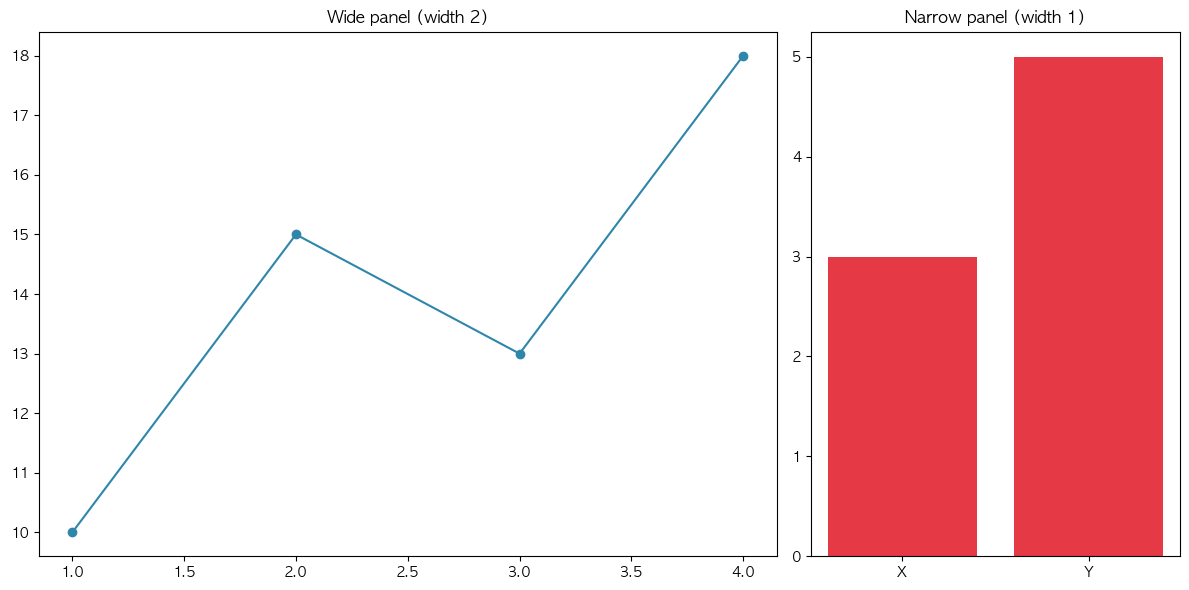

In [2]:
# Common Variations: an uneven 2:1 width split
# 주요 변형: 2:1 비율의 불균등 너비 분할

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[2, 1])   # left : right = 2 : 1

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

ax1.plot([1, 2, 3, 4], [10, 15, 13, 18], marker='o', color='#2E86AB')
ax1.set_title('Wide panel (width 2)')

ax2.bar(['X', 'Y'], [3, 5], color='#E63946')
ax2.set_title('Narrow panel (width 1)')

plt.tight_layout()
plt.show()

---
# 🧪 Small Examples · 예제

## Example 1: subplot_mosaic — Layout as a Picture · 예제 1: subplot_mosaic — 그림처럼 그리는 레이아웃

Each character in the layout string is one Axes. `'A'` occupying a 2x2 block, `'B'`/`'C'` each taking one cell, and `'D'` spanning the bottom row is *visible directly in the string* — no mental translation needed. The return value is a dict (`axd`), not an array, so you address panels by name: `axd['A']`.

레이아웃 문자열의 각 글자가 하나의 Axes입니다. `'A'`가 2x2 블록을 차지하고, `'B'`/`'C'`가 각각 한 칸씩, `'D'`가 하단 행 전체를 차지하는 모습이 *문자열 자체에서 바로 보입니다* — 머릿속으로 변환할 필요가 없습니다. 반환값은 배열이 아니라 딕셔너리(`axd`)이므로, 이름으로 패널에 접근합니다: `axd['A']`.

⚠️ Important constraint: the area each character occupies must form a rectangle. A layout like `"AAB\nBAA"` (where A and B interlock in a staircase) raises `ValueError: ... specifies a non-rectangular or non-contiguous area`.

⚠️ 중요한 제약: 같은 글자가 차지하는 영역은 반드시 직사각형이어야 합니다. `"AAB\nBAA"`처럼 A와 B가 계단 모양으로 얽히면 `ValueError: ... specifies a non-rectangular or non-contiguous area`가 발생합니다.

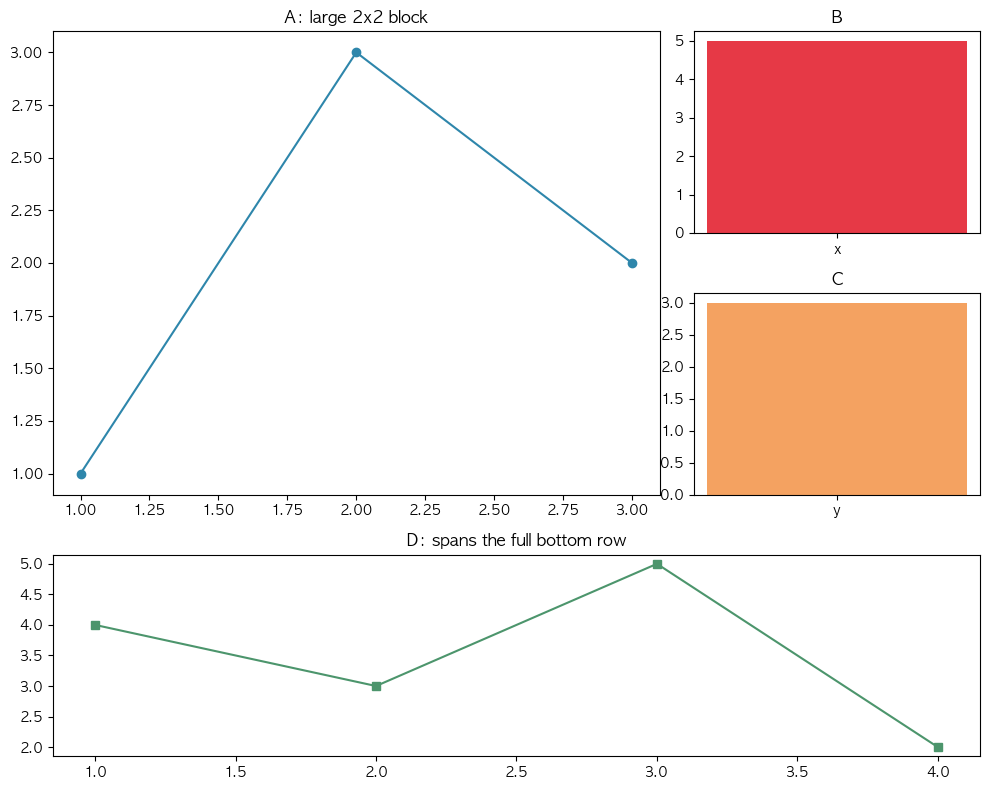

In [3]:
# Example 1: a dashboard-style layout defined entirely as a string
# 예제 1: 문자열만으로 정의하는 대시보드 스타일 레이아웃

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

layout = """
AAB
AAC
DDD
"""

fig, axd = plt.subplot_mosaic(layout, figsize=(10, 8))

axd['A'].plot([1, 2, 3], [1, 3, 2], marker='o', color='#2E86AB')
axd['A'].set_title('A: large 2x2 block')

axd['B'].bar(['x'], [5], color='#E63946')
axd['B'].set_title('B')

axd['C'].bar(['y'], [3], color='#F4A261')
axd['C'].set_title('C')

axd['D'].plot([1, 2, 3, 4], [4, 3, 5, 2], marker='s', color='#4C956C')
axd['D'].set_title('D: spans the full bottom row')

plt.tight_layout()
plt.show()

## Example 2: Practice · 예제 2: 연습문제

Rebuild a weekly traffic dashboard: a full-width trend on top, a visitor-type bar chart bottom-left, a device-share pie bottom-right. Fill in the two height ratios below — it runs without error either way, and the real dashboard only appears once both blanks are filled in.

주간 트래픽 대시보드를 다시 만들어보세요: 상단에는 전체 너비 추세선, 하단 왼쪽에는 방문자 유형 막대, 하단 오른쪽에는 디바이스 비중 파이 차트. 아래 두 높이 비율을 채우세요 — 어떤 상태든 에러 없이 실행되며, 두 빈칸을 모두 채워야 실제 대시보드가 나타납니다.

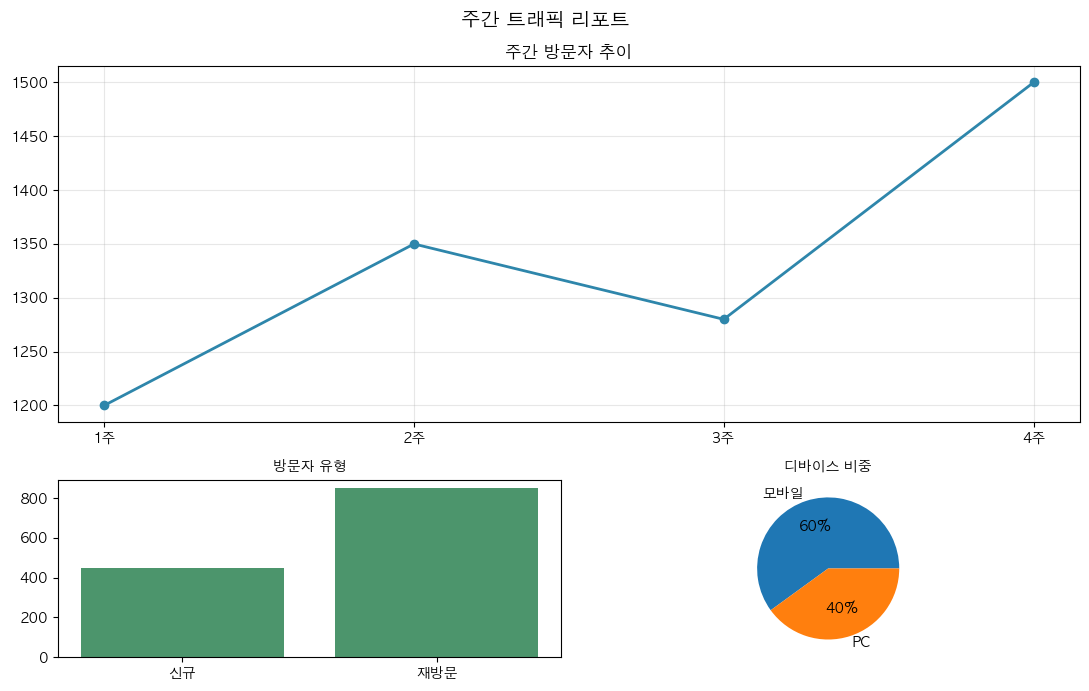

In [7]:
# Practice: fill in the blanks, then re-run this cell
# 연습문제: 빈칸을 채운 후 셀을 다시 실행하세요

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

weeks = ['1주', '2주', '3주', '4주']
visitors = [1200, 1350, 1280, 1500]
visitor_types = {'신규': 450, '재방문': 850}
device_share = {'모바일': 60, 'PC': 40}

height_ratio_top = 2      # TODO: a number, e.g. 2
height_ratio_bottom = 1   # TODO: a number, e.g. 1

if height_ratio_top == "________" or height_ratio_bottom == "________":
    print("Fill in height_ratio_top and height_ratio_bottom above, then re-run.")
    print("위의 height_ratio_top, height_ratio_bottom을 채운 후 다시 실행하세요.")
else:
    fig = plt.figure(figsize=(11, 7))
    gs = fig.add_gridspec(2, 2, height_ratios=[height_ratio_top, height_ratio_bottom])

    ax_main = fig.add_subplot(gs[0, :])
    ax_main.plot(weeks, visitors, marker='o', color='#2E86AB', linewidth=2)
    ax_main.set_title('주간 방문자 추이')
    ax_main.grid(True, alpha=0.3)

    ax_left = fig.add_subplot(gs[1, 0])
    ax_left.bar(list(visitor_types.keys()), list(visitor_types.values()), color='#4C956C')
    ax_left.set_title('방문자 유형', fontsize=10)

    ax_right = fig.add_subplot(gs[1, 1])
    ax_right.pie(list(device_share.values()), labels=list(device_share.keys()), autopct='%1.0f%%')
    ax_right.set_title('디바이스 비중', fontsize=10)

    fig.suptitle('주간 트래픽 리포트', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
# ⚠️ Common Mistakes · 자주 하는 실수

### Mistake 1: Treating GridSpec cells as single integers only · 실수 1: GridSpec을 개별 정수로만 다루고 슬라이싱을 활용 못함

Without slicing, every panel ends up occupying exactly one cell — the whole point of GridSpec (panels spanning multiple cells) is never actually used, making it no different from plain `plt.subplots()`.

슬라이싱을 활용하지 않으면 모든 패널이 정확히 한 칸씩만 차지하게 되어, GridSpec의 핵심 장점(여러 칸에 걸친 배치)을 전혀 활용하지 못하고 결국 `plt.subplots()`와 다를 바 없어집니다.

✅ **Fix:** Use numpy-style slicing like `gs[0, :]` or `gs[2, 1:]`, exactly as in Basic Syntax and the Business Example below.  
✅ **해결:** 아래 Basic Syntax와 Business Example처럼 `gs[0, :]`, `gs[2, 1:]`같은 numpy 스타일 슬라이싱을 활용하세요.

### Mistake 2: Trusting tight_layout() alone with 6+ subplots · 실수 2: 서브플롯이 6개 이상인데 tight_layout()만 믿음

`tight_layout()` does a reasonable job automatically, but once a dashboard has many panels, titles and labels frequently still collide.

`tight_layout()`은 자동으로 어느 정도 잘 처리해주지만, 대시보드에 패널이 많아지면 제목·라벨이 여전히 서로 겹치는 경우가 흔합니다.

✅ **Fix:** Set `hspace` and `wspace` explicitly when creating the GridSpec, as the Business Example below does.  
✅ **해결:** 아래 Business Example처럼 GridSpec을 만들 때 `hspace`, `wspace`를 직접 지정하세요.

### Mistake 3: Forgetting axis('off') on text-only Axes · 실수 3: 텍스트 전용(KPI 카드) Axes에 axis('off') 누락

A KPI number card built from `ax.text()` calls still shows an unwanted box border and tick marks around it unless the axis is explicitly turned off.

`ax.text()` 호출로 만든 KPI 숫자 카드도, 축을 명시적으로 끄지 않으면 원치 않는 테두리와 눈금이 그 주위에 함께 표시됩니다.

✅ **Fix:** Always call `ax.axis('off')` on any Axes that holds no actual chart.  
✅ **해결:** 실제 차트가 없는 Axes에는 항상 `ax.axis('off')`를 호출하세요.

### Mistake 4: Confusing fig.suptitle() with ax.set_title() · 실수 4: fig.suptitle()과 ax.set_title()을 혼동

Using `ax.set_title()` when you meant the whole Figure's title either leaves the dashboard without an overall title, or makes one panel's title look oversized and out of place.

Figure 전체 제목을 의도했는데 `ax.set_title()`을 쓰면, 대시보드에 전체 제목이 없거나 한 패널의 제목이 지나치게 크고 어색해 보이게 됩니다.

✅ **Fix:** Use `fig.suptitle()` for the Figure's overall title and `ax.set_title()` for each individual panel's title.  
✅ **해결:** Figure 전체 제목은 `fig.suptitle()`, 각 서브플롯 제목은 `ax.set_title()`로 구분해서 사용하세요.

### Mistake 5: A non-rectangular subplot_mosaic layout string · 실수 5: subplot_mosaic 레이아웃 문자열에서 같은 글자가 직사각형을 이루지 않음

Letting the same character occupy a staircase or L-shaped region raises `ValueError: ... specifies a non-rectangular or non-contiguous area`.

같은 글자가 계단 모양이나 L자 모양의 영역을 차지하게 두면 `ValueError: ... specifies a non-rectangular or non-contiguous area`가 발생합니다.

✅ **Fix:** Design the layout string so every character's region is always a clean rectangle, as in Example 1 above.  
✅ **해결:** 위 Example 1처럼 각 글자가 차지하는 영역이 항상 깔끔한 사각형이 되도록 레이아웃 문자열을 설계하세요.

---
# 💡 Tips · 팁
Useful tips or shortcuts · 유용한 팁과 지름길

- Start simple: use `plt.subplots()` when every panel is equally important, and reach for `GridSpec` only once you need uneven sizes or a panel that spans multiple cells.  
단순하게 시작하세요: 모든 패널이 대등하게 중요하면 `plt.subplots()`를, 크기가 불균등하거나 여러 칸에 걸친 패널이 필요할 때만 `GridSpec`을 쓰세요.
- With many panels, always set `hspace`/`wspace` explicitly on the GridSpec itself rather than hoping `tight_layout()` handles everything alone.  
패널이 많다면 `tight_layout()`에만 맡기지 말고 GridSpec 자체에 `hspace`/`wspace`를 직접 지정하세요.
- A KPI number card is just an Axes with `axis('off')` and two `ax.text()` calls — a reusable trick anywhere you need a "big number" tile.  
KPI 숫자 카드는 그저 `axis('off')`와 `ax.text()` 호출 2개로 만든 Axes일 뿐입니다 — "큰 숫자" 타일이 필요할 때마다 재사용할 수 있는 기법입니다.
- Before writing any `subplot_mosaic` code, sketch the dashboard on paper first, then transcribe the sketch directly into the layout string.  
`subplot_mosaic` 코드를 쓰기 전에 대시보드를 먼저 종이에 스케치하고, 그 스케치를 그대로 레이아웃 문자열로 옮기세요.

---
# 🔗 Related Concepts · 관련 개념

```
   Section 8: Composite & Special Charts
   (combining techniques WITHIN one chart)
                ↓
   Section 9: Subplots & Dashboards   ←  YOU ARE HERE / 지금 여기
   (combining entire CHARTS into one report)
                ↓
   = Section 1's "Reporting" stage, now fully built
                ↓
              Tableau   (the next tool in the curriculum)
```

*How is today's topic connected to other concepts?* · *오늘 배운 내용이 다른 개념과 어떻게 연결되는가?*

This section closes the loop that Section 1 opened. Back in Section 1's 3-role table, "Communication" was the role aimed at leadership and non-technical teams — a Section 9 dashboard *is* that role, fully built. Every chart type from Sections 3-8 (Line, Bar, Pie, Heatmap, and everything between) can become one panel inside a GridSpec dashboard exactly like the one in the Business Example below. From here, Section 1's own roadmap points to Tableau next — a no-code way to share this same kind of dashboard with people who don't write Python.

이 섹션은 섹션 1에서 열어둔 이야기를 마무리합니다. 섹션 1의 3가지 역할 표에서 "커뮤니케이션"은 경영진과 비개발자 대상의 역할이었습니다 — 섹션 9의 대시보드가 바로 그 역할을 완성된 형태로 보여줍니다. 섹션 3~8의 모든 차트 유형(Line, Bar, Pie, Heatmap 등)은 아래 Business Example과 같은 GridSpec 대시보드 안의 패널 하나가 될 수 있습니다. 여기서부터는 섹션 1이 제시한 로드맵대로 다음은 Tableau입니다 — 파이썬 코드를 쓰지 않는 사람들과 같은 종류의 대시보드를 공유하는 코드 없는(no-code) 방법입니다.

---
# 💼 Business Example · 비즈니스 예제
*How would a Business Analyst use this?* · *비즈니스 분석가는 이것을 어떻게 활용할까?*

**Scenario / 시나리오:**
It's the end of H1. Your manager wants one image for the leadership deck: this month's revenue, the target achievement rate, month-over-month growth, the full 6-month trend against target, channel composition, and a product ranking — all in a single, well-organized page.

상반기가 끝났습니다. 매니저가 경영진 발표 자료용으로 이미지 하나를 요청합니다: 이번 달 매출, 목표 달성률, 전월 대비 성장률, 6개월 전체 추세 대 목표선, 채널 구성비, 제품 순위 — 이 모든 것을 잘 정리된 한 페이지에 담아야 합니다.

**To-Do / 할 일:**
- [x] Build 3 KPI number cards across the top row using `axis('off')` Axes  
상단 행에 `axis('off')` Axes로 KPI 숫자 카드 3개 만들기
- [x] Add a full-width trend line with a target reference line in the middle row  
중단 행에 목표선이 포함된 전체 너비 추세선 추가하기
- [x] Add a channel-composition pie and a product-ranking bar side by side (1:2 width) on the bottom row  
하단 행에 채널 구성 파이와 제품 순위 막대를 1:2 너비로 나란히 배치하기

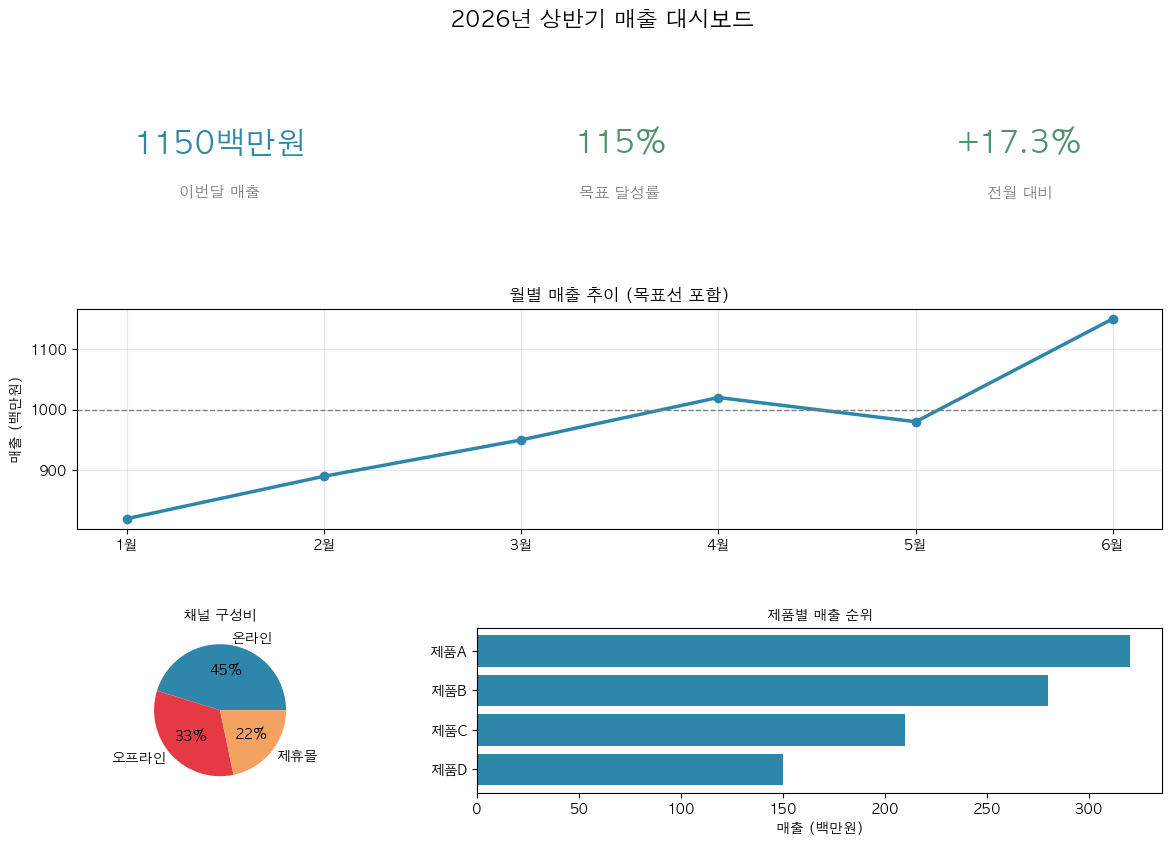

6-month cumulative revenue / 6개월 누적 매출: 5810백만원
Monthly average / 월평균: 968백만원


In [5]:
# Business Example: comprehensive H1 sales KPI dashboard
# 비즈니스 예제: 종합 상반기 매출 KPI 대시보드

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# self-contained dataset / 자체 포함형 데이터셋
months = ['1월', '2월', '3월', '4월', '5월', '6월']
revenue = [820, 890, 950, 1020, 980, 1150]
target = 1000
channels = ['온라인', '오프라인', '제휴몰']
channel_sales = [520, 380, 250]
top_products = ['제품A', '제품B', '제품C', '제품D']
product_sales = [320, 280, 210, 150]

total_revenue = sum(revenue)
avg_revenue = np.mean(revenue)
achievement = revenue[-1] / target * 100
mom_growth = (revenue[-1] - revenue[-2]) / revenue[-2] * 100

fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(3, 3, height_ratios=[1, 2, 1.5], hspace=0.6, wspace=0.4)

# (1) top row: 3 KPI number cards (text-only Axes)
# (1) 상단 행: KPI 숫자 카드 3개 (텍스트만 있는 Axes)
kpi_data = [
    ('이번달 매출', f'{revenue[-1]}백만원', '#2E86AB'),
    ('목표 달성률', f'{achievement:.0f}%', '#4C956C' if achievement >= 100 else '#E63946'),
    ('전월 대비', f'{mom_growth:+.1f}%', '#4C956C' if mom_growth >= 0 else '#E63946'),
]
for i, (label, value, color) in enumerate(kpi_data):
    ax = fig.add_subplot(gs[0, i])
    ax.text(0.5, 0.6, value, ha='center', va='center', fontsize=22, fontweight='bold', color=color)
    ax.text(0.5, 0.15, label, ha='center', va='center', fontsize=11, color='gray')
    ax.axis('off')

# (2) middle row: full-width trend vs target (gs[1, :] spans all 3 columns)
# (2) 중단 행: 목표 대비 전체 너비 추세 (gs[1, :]가 3개 열 전체를 차지)
ax_trend = fig.add_subplot(gs[1, :])
ax_trend.plot(months, revenue, marker='o', color='#2E86AB', linewidth=2.5)
ax_trend.axhline(y=target, color='gray', linestyle='--', linewidth=1)
ax_trend.set_title('월별 매출 추이 (목표선 포함)')
ax_trend.set_ylabel('매출 (백만원)')
ax_trend.grid(True, alpha=0.3)

# (3) bottom-left: channel composition pie
# (3) 하단 왼쪽: 채널 구성비 파이
ax_pie = fig.add_subplot(gs[2, 0])
ax_pie.pie(channel_sales, labels=channels, autopct='%1.0f%%', colors=['#2E86AB', '#E63946', '#F4A261'])
ax_pie.set_title('채널 구성비', fontsize=10)

# (4) bottom-right (2 cols): product ranking bar (gs[2, 1:] spans columns 1-2)
# (4) 하단 오른쪽(2칸): 제품별 매출 순위 (gs[2, 1:]가 1~2번 열을 차지)
ax_bar = fig.add_subplot(gs[2, 1:])
ax_bar.barh(top_products[::-1], product_sales[::-1], color='#2E86AB')
ax_bar.set_title('제품별 매출 순위', fontsize=10)
ax_bar.set_xlabel('매출 (백만원)')

fig.suptitle('2026년 상반기 매출 대시보드', fontsize=16, fontweight='bold')
fig.savefig('sales_kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"6-month cumulative revenue / 6개월 누적 매출: {total_revenue}백만원")
print(f"Monthly average / 월평균: {avg_revenue:.0f}백만원")

---
# 📝 Summary · 요약
*Write today's concept in 3~5 sentences.* · *오늘 배운 개념을 3~5문장으로 정리하세요.*

`plt.subplots()` covers an evenly-sized grid, but `GridSpec` and `subplot_mosaic` handle everything beyond that: `GridSpec` slices like a numpy array (`gs[0, :]`) to let one panel span multiple cells, and its `width_ratios`/`height_ratios` control relative panel sizes, while `subplot_mosaic` lets you write the layout as a string that visually resembles the final picture, addressing panels by name through a dict instead of an array. A KPI number card is nothing more than an Axes with `axis('off')` and a couple of `ax.text()` calls, and it combines with a trend line, a pie chart, and a bar chart — all built in earlier sections — into a single one-page dashboard. The most common failure points are forgetting to slice GridSpec at all, relying on `tight_layout()` alone instead of setting `hspace`/`wspace`, and building a `subplot_mosaic` layout string where a character's region isn't a clean rectangle. This dashboard-building skill is the concrete, hands-on version of the "Communication" role first introduced all the way back in Section 1.

`plt.subplots()`는 균등한 격자를 다루지만, 그 이상은 `GridSpec`과 `subplot_mosaic`이 처리합니다: `GridSpec`은 numpy 배열처럼 슬라이싱해서(`gs[0, :]`) 한 패널이 여러 칸에 걸치게 하고, `width_ratios`/`height_ratios`로 패널의 상대적 크기를 조절하며, `subplot_mosaic`은 최종 그림과 비슷하게 생긴 문자열로 레이아웃을 작성하고 배열 대신 딕셔너리로 이름을 통해 패널에 접근합니다. KPI 숫자 카드는 `axis('off')`와 `ax.text()` 호출 몇 개로 이루어진 Axes에 불과하며, 이전 섹션들에서 만든 추세선·파이 차트·막대 차트와 결합해 하나의 원페이지 대시보드가 됩니다. 가장 흔한 실패 지점은 GridSpec을 아예 슬라이싱하지 않는 것, `hspace`/`wspace` 설정 대신 `tight_layout()`에만 의존하는 것, 그리고 `subplot_mosaic` 레이아웃 문자열에서 한 글자의 영역이 깔끔한 사각형이 아닌 것입니다. 이 대시보드 제작 스킬은 섹션 1에서 처음 소개된 "커뮤니케이션" 역할의 구체적이고 실전적인 버전입니다.

---
# 📌 One Sentence Summary · 한 줄 요약
Today's topic in ONE sentence. · 오늘의 주제를 한 문장으로.

> GridSpec and subplot_mosaic turn every chart type learned in this course into one panel of a single, well-organized dashboard — the concrete finish line of the "Communication" role Section 1 promised at the very start.

> GridSpec과 subplot_mosaic은 이 강의에서 배운 모든 차트 유형을 하나의 잘 정리된 대시보드 안의 패널 하나로 만들어주며 — 이는 섹션 1이 맨 처음 약속했던 "커뮤니케이션" 역할의 구체적인 결승선이다.

---
# ❓ Review Questions · 복습 문제

**Q1.** What's the key difference between `plt.subplots(nrows, ncols)` and `fig.add_gridspec(nrows, ncols)` in terms of what each one lets you do?
`plt.subplots(nrows, ncols)`와 `fig.add_gridspec(nrows, ncols)`는 각각 할 수 있는 일에 있어 핵심적인 차이가 무엇인가?

subplots() makes an even grid. GridSpec is a blueprint you slice so one panel can span several cells.  
subplots()는 균등 격자, gridspec은 잘라서 칸을 합칠 수 있는 설계도입니다.

**Q2.** What does `gs[1, :]` mean, and what would `gs[:, 0]` mean instead?
`gs[1, :]`는 무엇을 의미하며, `gs[:, 0]`이라면 대신 무엇을 의미하겠는가?

gs[1, :] spans the full second row; gs[:, 0] spans the full first column.  
둘째 행을 가로로, 첫째 열을 세로로 길게 씁니다.

**Q3.** In `subplot_mosaic`, why is the returned object a dictionary instead of an array, and what constraint must every character's region satisfy?
`subplot_mosaic`에서 반환값은 왜 배열이 아니라 딕셔너리이며, 각 글자의 영역은 어떤 제약을 만족해야 하는가?

It returns a dict so you address panels by name. Each letter’s region must be a rectangle.  
이름(axd['A'])으로 접근하려고 dict입니다. 한 글자의 영역은 직사각형이어야 합니다.

**Q4.** How do you build a "KPI number card," and why is `axis('off')` a necessary part of it?
"KPI 숫자 카드"는 어떻게 만들며, `axis('off')`가 왜 그 필수적인 부분인가?

A KPI card is a text-only Axes: ax.text() plus axis('off') so ticks and the frame disappear.  
숫자만 있는 칸입니다. 축을 꺼야 테두리·눈금이 안 남습니다.

**Q5.** What's the difference between `fig.suptitle()` and `ax.set_title()`, and what goes wrong if you use the wrong one for a dashboard's overall title?
`fig.suptitle()`과 `ax.set_title()`의 차이는 무엇이며, 대시보드의 전체 제목에 잘못된 것을 사용하면 어떤 문제가 생기는가?

fig.suptitle() titles the whole figure; ax.set_title() titles one panel. Using the Axes title for the dashboard puts it on a single chart only.  
전체 제목은 suptitle, 패널 제목은 set_title입니다. 바꾸면 제목이 한 그래프에만 붙습니다.

---
*📅 Try answering these again in a few days.* · *📅 며칠 후에 다시 답해보세요.*